<a href="https://colab.research.google.com/github/Madhavan777/DAA-Exp-1/blob/main/DAA_Exp_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generated 10,000 sorted floats uniformly distributed in [0.0, 1000.0].
Sample: [0.3144, 0.4169, 0.5187, 0.5681, 0.5711] ... [999.5181, 999.7149, 999.7653, 999.8608, 999.977]

INDIVIDUAL SEARCH COMPARISON (n = 10,000)
+------------+-----------+---------------+----------------------+
| Value      | Status    | Binary Probes | Interpolation Probes |
+------------+-----------+---------------+----------------------+
| 178.924786 | Found     | 10            | 4                    |
| 40.527034  | Found     | 13            | 5                    |
| 447.125550 | Found     | 13            | 4                    |
| 397.333884 | Found     | 10            | 4                    |
| 362.173676 | Found     | 12            | 3                    |
| 139.537929 | Not found | 14            | 2                    |
| 102.495176 | Not found | 14            | 4                    |
| 740.667745 | Not found | 13            | 4                    |
+------------+-----------+---------------+---------------

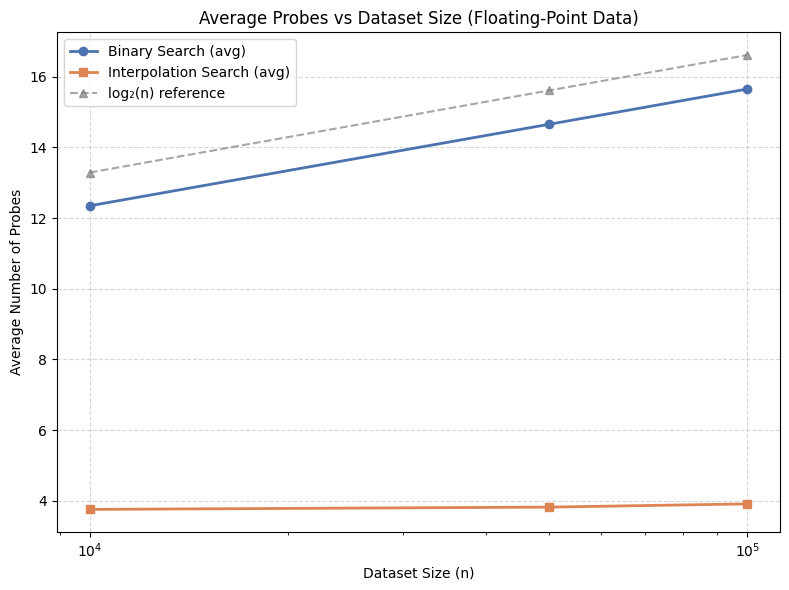

Saved line chart -> scaling_line_chart.png


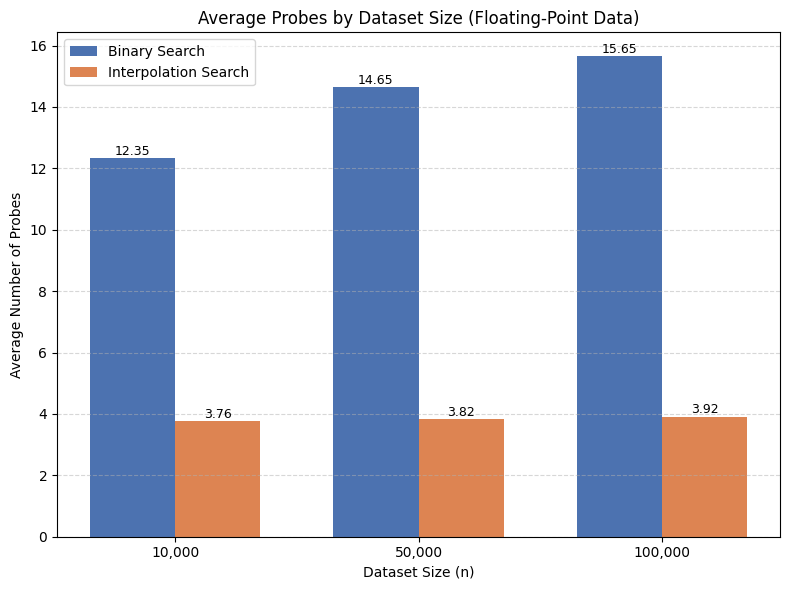

Saved bar chart -> scaling_bar_chart.png


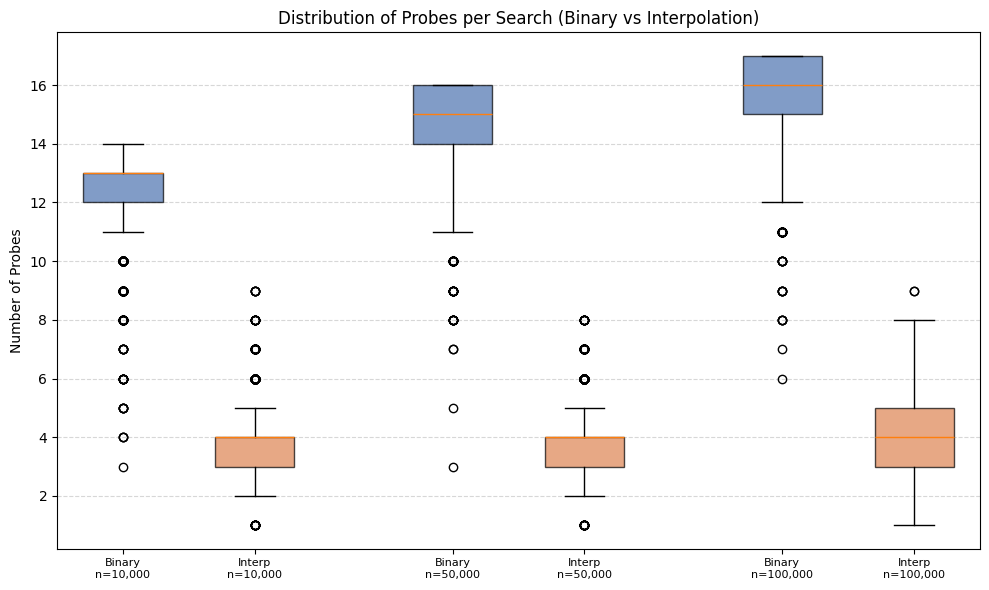

Saved box plot -> probe_distribution_box.png


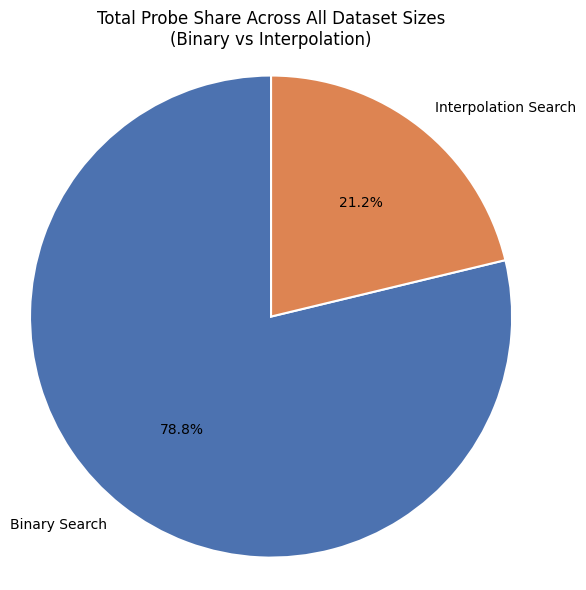

Saved pie chart -> total_probe_share_pie.png

Conclusion:
Binary Search's probe count grows in line with log2(n) - confirmed by how
closely its average tracks the log2(n) reference line across all three sizes.
Interpolation Search stays nearly flat (roughly 3-5 probes) even as n grows
100x from 10,000 to 100,000, because uniformly distributed floats let its
position estimate land close to the target almost every time. This matches
the theoretical O(log log n) average-case behavior of Interpolation Search
on uniform data, versus O(log n) for Binary Search - and the gap widens as
the dataset grows larger.


In [1]:
"""
Interpolation Search vs Binary Search on Floating-Point Data
Sorted arrays of floats uniformly distributed in [0.0, 1000.0]
Analyzes probe counts across different dataset sizes: 10,000 / 50,000 / 100,000
"""

import random
import numpy as np
import matplotlib.pyplot as plt


# ---------- Data generation ----------

def generate_sorted_floats(n, low=0.0, high=1000.0, seed=None):
    """Generate a sorted numpy array of n floats, uniformly distributed."""
    rng = np.random.default_rng(seed)
    arr = rng.uniform(low, high, n)
    arr.sort()
    return arr


# ---------- Search algorithms (float-aware) ----------

def binary_search(arr, key):
    """Binary search for floats. Returns (index or -1, probes)."""
    low, high = 0, len(arr) - 1
    probes = 0

    while low <= high:
        probes += 1
        mid = (low + high) // 2

        if arr[mid] == key:
            return mid, probes
        elif arr[mid] < key:
            low = mid + 1
        else:
            high = mid - 1

    return -1, probes


def interpolation_search(arr, key, eps=1e-9):
    """
    Interpolation search adapted for floating-point arrays.
    Uses real-valued interpolation to estimate the likely position, then
    rounds to the nearest integer index. eps handles float equality safely.
    """
    low, high = 0, len(arr) - 1
    probes = 0

    while low <= high and arr[low] - eps <= key <= arr[high] + eps:
        probes += 1

        if abs(arr[high] - arr[low]) < eps:
            if abs(arr[low] - key) < eps:
                return low, probes
            break

        # Real-valued interpolation formula, then round to nearest index
        fraction = (key - arr[low]) / (arr[high] - arr[low])
        pos = low + int(fraction * (high - low))
        pos = max(low, min(high, pos))  # clamp into valid bounds

        if abs(arr[pos] - key) < eps:
            return pos, probes
        elif arr[pos] < key:
            low = pos + 1
        else:
            high = pos - 1

    return -1, probes


def compare_search(arr, key):
    """Run both searches on a single float key and return a result row."""
    bin_idx, bin_probes = binary_search(arr, key)
    interp_idx, interp_probes = interpolation_search(arr, key)

    status = "Found" if bin_idx != -1 else "Not found"

    return {
        "value": key,
        "status": status,
        "bin_probes": bin_probes,
        "interp_probes": interp_probes,
    }


def print_table(headers, rows):
    """Print a list of equal-length row tuples as a clean ASCII table."""
    col_widths = [len(h) for h in headers]
    for row in rows:
        for i, cell in enumerate(row):
            col_widths[i] = max(col_widths[i], len(str(cell)))

    def format_row(row):
        return "| " + " | ".join(
            str(cell).ljust(col_widths[i]) for i, cell in enumerate(row)
        ) + " |"

    separator = "+-" + "-+-".join("-" * w for w in col_widths) + "-+"

    print(separator)
    print(format_row(headers))
    print(separator)
    for row in rows:
        print(format_row(row))
    print(separator)


# ---------- Scaling analysis across dataset sizes ----------

def run_scaling_analysis(sizes, trials=2000, seed=42):
    """For each dataset size, generate a sorted float array and measure
    probe statistics over many random existing-key searches."""
    rng = random.Random(seed)
    results = []

    for n in sizes:
        arr = generate_sorted_floats(n, seed=seed)
        bin_probes_list = []
        interp_probes_list = []

        for _ in range(trials):
            key = arr[rng.randrange(n)]  # guaranteed existing key
            _, bp = binary_search(arr, key)
            _, ip = interpolation_search(arr, key)
            bin_probes_list.append(bp)
            interp_probes_list.append(ip)

        results.append({
            "n": n,
            "bin_avg": float(np.mean(bin_probes_list)),
            "bin_min": int(np.min(bin_probes_list)),
            "bin_max": int(np.max(bin_probes_list)),
            "interp_avg": float(np.mean(interp_probes_list)),
            "interp_min": int(np.min(interp_probes_list)),
            "interp_max": int(np.max(interp_probes_list)),
            "log2_n": float(np.log2(n)),
            "bin_probes_list": bin_probes_list,
            "interp_probes_list": interp_probes_list,
        })

    return results


# ---------- Charts ----------

def plot_scaling_line(results, save_path="scaling_line_chart.png"):
    """Line chart: average probes vs dataset size, with a log2(n) reference."""
    sizes = [r["n"] for r in results]
    bin_avgs = [r["bin_avg"] for r in results]
    interp_avgs = [r["interp_avg"] for r in results]
    log2_vals = [r["log2_n"] for r in results]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(sizes, bin_avgs, marker="o", label="Binary Search (avg)",
             color="#4C72B0", linewidth=2)
    ax.plot(sizes, interp_avgs, marker="s", label="Interpolation Search (avg)",
             color="#DD8452", linewidth=2)
    ax.plot(sizes, log2_vals, marker="^", linestyle="--",
             label="log\u2082(n) reference", color="gray", alpha=0.7)

    ax.set_xlabel("Dataset Size (n)")
    ax.set_ylabel("Average Number of Probes")
    ax.set_title("Average Probes vs Dataset Size (Floating-Point Data)")
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved line chart -> {save_path}")


def plot_scaling_bar(results, save_path="scaling_bar_chart.png"):
    """Grouped bar chart: average probes per dataset size."""
    labels = [f"{r['n']:,}" for r in results]
    bin_avgs = [r["bin_avg"] for r in results]
    interp_avgs = [r["interp_avg"] for r in results]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 6))
    bars1 = ax.bar(x - width / 2, bin_avgs, width, label="Binary Search", color="#4C72B0")
    bars2 = ax.bar(x + width / 2, interp_avgs, width, label="Interpolation Search", color="#DD8452")

    for bar in list(bars1) + list(bars2):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1,
                 f"{height:.2f}", ha="center", fontsize=9)

    ax.set_xlabel("Dataset Size (n)")
    ax.set_ylabel("Average Number of Probes")
    ax.set_title("Average Probes by Dataset Size (Floating-Point Data)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved bar chart -> {save_path}")


def plot_probe_distribution_box(results, save_path="probe_distribution_box.png"):
    """Box plot of probe-count distributions, Binary vs Interpolation, per size."""
    fig, ax = plt.subplots(figsize=(10, 6))

    data, tick_labels, positions = [], [], []
    pos = 1
    for r in results:
        data.append(r["bin_probes_list"])
        tick_labels.append(f"Binary\nn={r['n']:,}")
        positions.append(pos)
        pos += 1

        data.append(r["interp_probes_list"])
        tick_labels.append(f"Interp\nn={r['n']:,}")
        positions.append(pos)
        pos += 1.5

    colors = (["#4C72B0", "#DD8452"] * len(results))

    bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks(positions)
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_ylabel("Number of Probes")
    ax.set_title("Distribution of Probes per Search (Binary vs Interpolation)")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved box plot -> {save_path}")


def plot_total_share_pie(results, save_path="total_probe_share_pie.png"):
    """Pie chart: each algorithm's share of total probes across all sizes/trials."""
    total_bin = sum(sum(r["bin_probes_list"]) for r in results)
    total_interp = sum(sum(r["interp_probes_list"]) for r in results)

    labels = ["Binary Search", "Interpolation Search"]
    values = [total_bin, total_interp]
    colors = ["#4C72B0", "#DD8452"]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(values, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
    ax.set_title("Total Probe Share Across All Dataset Sizes\n(Binary vs Interpolation)")
    ax.axis("equal")

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved pie chart -> {save_path}")


def main():
    random.seed(42)

    # ---- Part 1: individual search demo on a 10,000-element float array ----
    demo_n = 10000
    demo_arr = generate_sorted_floats(demo_n, seed=42)

    print(f"Generated {demo_n:,} sorted floats uniformly distributed in [0.0, 1000.0].")
    print(f"Sample: {[round(float(v), 4) for v in demo_arr[:5]]} ... "
          f"{[round(float(v), 4) for v in demo_arr[-5:]]}\n")

    existing_idx = random.sample(range(demo_n), 5)
    existing_keys = [demo_arr[i] for i in existing_idx]
    missing_keys = [round(random.uniform(0, 1000), 6) for _ in range(3)]
    test_keys = existing_keys + missing_keys

    print("INDIVIDUAL SEARCH COMPARISON (n = 10,000)")
    demo_results = [compare_search(demo_arr, key) for key in test_keys]
    demo_table_rows = [
        (f"{r['value']:.6f}", r["status"], r["bin_probes"], r["interp_probes"])
        for r in demo_results
    ]
    print_table(
        ["Value", "Status", "Binary Probes", "Interpolation Probes"],
        demo_table_rows,
    )

    # ---- Part 2: scaling analysis across dataset sizes ----
    sizes = [10000, 50000, 100000]
    trials = 2000
    print(f"\nRunning scaling analysis for sizes {sizes} "
          f"({trials} random searches each)...")
    scaling_results = run_scaling_analysis(sizes, trials=trials, seed=42)

    print("\nSCALING ANALYSIS: AVERAGE PROBES BY DATASET SIZE")
    scaling_table_rows = [
        (
            f"{r['n']:,}",
            f"{r['bin_avg']:.3f}",
            f"{r['interp_avg']:.3f}",
            f"{r['log2_n']:.2f}",
        )
        for r in scaling_results
    ]
    print_table(
        ["Dataset Size (n)", "Avg Binary Probes", "Avg Interpolation Probes", "log2(n) Reference"],
        scaling_table_rows,
    )

    print("\nMIN / MAX PROBES BY DATASET SIZE")
    minmax_rows = [
        (
            f"{r['n']:,}",
            f"{r['bin_min']} - {r['bin_max']}",
            f"{r['interp_min']} - {r['interp_max']}",
        )
        for r in scaling_results
    ]
    print_table(
        ["Dataset Size (n)", "Binary (min-max)", "Interpolation (min-max)"],
        minmax_rows,
    )

    # ---- Charts ----
    plot_scaling_line(scaling_results)
    plot_scaling_bar(scaling_results)
    plot_probe_distribution_box(scaling_results)
    plot_total_share_pie(scaling_results)

    print("\nConclusion:")
    print("Binary Search's probe count grows in line with log2(n) - confirmed by how")
    print("closely its average tracks the log2(n) reference line across all three sizes.")
    print("Interpolation Search stays nearly flat (roughly 3-5 probes) even as n grows")
    print("100x from 10,000 to 100,000, because uniformly distributed floats let its")
    print("position estimate land close to the target almost every time. This matches")
    print("the theoretical O(log log n) average-case behavior of Interpolation Search")
    print("on uniform data, versus O(log n) for Binary Search - and the gap widens as")
    print("the dataset grows larger.")


if __name__ == "__main__":
    main()
